In [11]:
import random
import pandas as pd
import numpy as np
from collections import Counter

In [ ]:
# 1.
# use randint(1,5) to generate uniform distribution between 1 to 7 (randint(1,7))
# rejection sampling

def roll_die():
    return random.randint(1,5)-1 # randint(start, end): both included

def generate_uniform_distribution(lower, upper):
    roll_again = True
    while roll_again:
        first_roll = roll_die()
        second_roll = roll_die()   
        number = first_roll*5 + second_roll # 0 - 24
        if lower <= number <= upper:
            return number + 1

In [4]:
result = []

for i in range(500000):
    result.append(generate_uniform_distribution(0, 6))

for i in range(1,8):
    print('the occurance for {} is {}'.format(i, result.count(i)))

the occurance for 1 is 71441
the occurance for 2 is 71683
the occurance for 3 is 71200
the occurance for 4 is 70968
the occurance for 5 is 71746
the occurance for 6 is 71631
the occurance for 7 is 71331


In [2]:
# 2.
# given a n-sided die, simulate how many times you need to roll the die such that every side is shown
# this is also known as the Coupon Collector's Problem

def roll_die(n):
    return random.randint(1,n)

def getCount(n):
    s = set()
    cnt = 0
    while len(s) < n:
        s.add(roll_die(n))
        cnt += 1
    return cnt

# ge the mean, median, and std of this value
def getstats(m, n):
    a = []
    for i in range(m):
        a.append(getCount(n))
    return [np.mean(a), np.median(a), np.std(a)]

In [5]:
getstats(100000, 6)

[14.68949, 13.0, 6.211350379740303]

In [37]:
# theorical solution of expected number of rolls

def expected_num(n):
    total = 0

    for i in range(1,n+1):
        total += n*(1/i)
    return total

In [38]:
expected_num(10)

29.289682539682538

In [ ]:
# coupon collector

import random

def coupon_collector(n):
    seen = set()
    times = 0

    while len(seen)<n:
        drawn = random.randint(1,n)
        times+=1
        if drawn not in seen:
            seen.add(drawn)
    return times

In [ ]:
results = []
sim_run = 100000
n = 10

for _ in range(sim_run):
    results.append(coupon_collector(10))

import numpy as numpy
print(np.mean(results))

In [ ]:
def expected_draw_num(n):
    total = 0
    for i in range(1,n):
        total += n*(1/i)
    return total

expected_draw_num(10)

In [39]:
# 3.
# calculate n factorial
# bottom up

def factorial(n):
    if n == 0 or n == 1:
        return 1
    memo = []
    memo.append(1)
    memo.append(1)
    for i in range(2,n+1):
        next = memo[i-1]*i
        memo.append(next)
    return memo[-1]

In [40]:
factorial(5)

120

In [47]:
# top down

def factorial_with_memo(n):
    memo = {}
    def factorial(n, memo):
        if n==0 or n==1:
            result = 1
        elif n in memo:
            result = memo[n]
        else:
            result = factorial(n-1, memo)*n
        memo[n] = result
        return result
    return factorial(n, memo)

In [48]:
factorial_with_memo(5)

120

In [51]:
# 4.
# calculate natural constant e without using any built-in function in python
# e = 1/0! + 1/1! + 1/2! + 1/3! + 1/4! + ...

def calculate_e(num_terms):
    e_approx = 1
    factorial = 1
    for i in range(1, num_terms):
        factorial *= i
        e_approx += 1/factorial
    return e_approx

In [14]:
calculate_e(100)

2.7182818284590455

In [28]:
# 5.
# simulation - one drunk passenger among 100 passengers
# result is 0.5

def drunk_passenger(n):
    all_seats = set(np.arange(1,n+1))
    taken = set()
    selection_sequence = []
    drunk_selection = random.randint(1,n)
    taken.add(drunk_selection)
    selection_sequence.append(drunk_selection)
    for i in range(2,n+1):
        available = all_seats - taken
        if i in taken:
            random_selection = random.choice(list(available))
            taken.add(random_selection)
            selection_sequence.append(random_selection)
        else:
            taken.add(i)
            selection_sequence.append(i)
    return selection_sequence[-1]

In [30]:
choices = []
simulation_num = 10000
num_passengers = 100

for i in range(simulation_num):
    choices.append(drunk_passenger(num_passengers))

Counter(choices)

Counter({1: 5042, 100: 4958})

In [29]:
# 6.
# simulation - coin toss game
# two players toss a die, whenever there is HT sequence, people toss T wins
# A go first, B go second
def coin_toss():
    selection = ['H', 'T']
    sequence = random.choices(selection, k=2) # random.choices, there is a s here
    while not (sequence[-2] == 'H' and sequence[-1] == 'T'):
        sequence.append(random.choice(selection))
    return len(sequence)%2 == 1

In [30]:
result = []

for i in range(100000):
    result.append(coin_toss())

result.count(True)/len(result)

0.44449

In [41]:
# 7.
# simulation - coin toss game
# A and B toss coins, if A appear HH, A win, if B appear HT B win, if appear together, tie
# the game continues until someone win
# calculate the probablity of winning for A and B

def coin_toss_two_sequences():
    sequence_A = []
    sequence_B = []
    selection = ['H', 'T']
    i=0
    while True:
        sequence_A.append(random.choice(selection))
        sequence_B.append(random.choice(selection))
        i+=1
        if i>=2 and sequence_A[-2:]==['H', 'H']:
            if sequence_B[-2:]==['H', 'T']:
                return "Tie"
            return "A"
        elif i>=2 and sequence_B[-2:]==['H', 'T']:
            return "B"

In [42]:
results = {"A": 0, "B": 0, "Tie": 0}
num_simulations = 100000
for _ in range (num_simulations):
    winner = coin_toss_two_sequences ()
    results[winner] += 1

prob_A_wins = results["A"]/num_simulations
prob_B_wins = results["B"]/num_simulations
prob_tie = results ["Tie"]/num_simulations
prob_A_wins, prob_B_wins, prob_tie

(0.32127, 0.53857, 0.14016)

In [119]:
# 8.
# simulation - Monty Hall

def monty_hall():
    items = ['goat', 'goat', 'car']
    guest_select_idx = random.randint(0,2)
    switch_false = items[guest_select_idx]

    items.pop(guest_select_idx)

    if items[0] == 'goat' and items[1] == 'goat':
        host_open_idx = random.randint(0,1)
    elif items[0] == 'goat':
        host_open_idx = 0
    else:
        host_open_idx = 1
    
    items.pop(host_open_idx)
    switch_true = items[0]

    return [switch_false, switch_true]

In [120]:
switch_false = []
switch_true = []

for _ in range(100000):
    result = monty_hall()
    switch_false.append(result[0])
    switch_true.append(result[1])

In [122]:
switch_false.count('car')/len(switch_false)

0.33218

In [121]:
switch_true.count('car')/len(switch_true)

0.66782

In [8]:
# 9.
# there ia an array contains only 0's and 1's. 
# you have one chance to change one 0 in the array to 1. 
# calculate the longest subarray where all elements are 1.
# use sliding window

def longest_subarray_of_1s_after_flip(arr):
    left = 0
    max_length = 0
    zero_count = 0

    for right in range(len(arr)):
        if arr[right] == 0:
            zero_count += 1
        while zero_count > 1:
            if arr[left] == 0:
                zero_count -= 1
            left += 1
        max_length = max(max_length, right - left + 1)
    return max_length

In [ ]:
arr = [1, 0, 1, 1, 0, 1, 0, 1, 1, 1]
longest_subarray_of_1s_after_flip(arr)

In [8]:
# 10.
# given two lists, one is actual, one is prediction, calculate root mean square error

actual = [1, 3, 5, 7, 10, 11, 14]
pred = [1, 2.5, 4, 8, 12, 12, 15]
rmse = np.sqrt(((np.array(actual) - np.array(pred))**2).sum()/len(actual))

In [9]:
rmse

1.0856202966836188

In [19]:
# 11.
# given a matrix, NOT allowed to use loop, calculate the row-wise and column-wise value that similar to entropy
# piecewise operation of numpy
# In this example, x**2 is applied to elements of x where x < -1, x**3 is applied where x > 1, and a default value of 10 is applied elsewhere.

x = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
conditions = [x<-1, x>1]
functions = [lambda x: x**2, lambda x: x**3]
result = np.piecewise(x, conditions, functions)

In [16]:
print(result)

[ 6.25   2.25   0.     0.     3.375 15.625]


In [55]:
# 12.
# simulation - calculate constant pi

import random
import numpy as np

# random.random() - will generate random number between 0 and 1
# random.uniform(0,2) - will generate random number betwen 0 and 2

def point_in_circle():
    x = random.uniform(-1,1)
    y = random.uniform(-1,1)
    if np.sqrt(x**2 + y**2) < 1:
        return True
    else:
        return False

In [56]:
n = 10000000
result = []
for i in range(n):
    result.append(point_in_circle())

# 4/(pi*r**2) = n/sum(result)
pi = 4*sum(result)/n
print(pi)

3.1416212


In [57]:
# 13.
# generate random normal variable

a = np.random.normal(0, 1, 100)

In [65]:
# 14
# Every day, you commute from your home to the office in the morning and return home in the evening.
# Say you have 1 umbrella, and it's either at home or in the office. 
# On each trip, you take that umbrella if it's with you and it's raining. 
# Assume that in every trip between home and office, the chance of raining is 1/2, independent of other trips.
# Figure out the probability of getting wet on a given day.
# Find analytical solution and code out the simulation.

import random

def simulate_days(num_days):
    umbrella_at_home = True
    wet_days = 0

    for _ in range(num_days):
        # Generate rain conditions for morning and evening
        rain_morning = random.uniform(0,1) < 0.5
        rain_evening = random.uniform(0,1) < 0.5

        # Morning commute
        if rain_morning and umbrella_at_home:
            umbrella_at_home = False  # Take the umbrella to the office
        elif rain_morning and not umbrella_at_home:
            wet_days += 1  # Get wet in the morning

        # Evening commute
        if rain_evening and not umbrella_at_home:
            umbrella_at_home = True  # Bring the umbrella back home
        elif rain_evening and umbrella_at_home:
            wet_days += 1  # Get wet in the evening

    return wet_days/num_days

In [66]:
# Simulate for a large number of days to estimate probability of getting wet
num_days = 100000
probability_getting_wet = simulate_days(num_days)
probability_getting_wet

0.33546

In [33]:
# 15.
# Assume you have a fair die, and toss it 6 times, each time you write down the number on the top side. 
# What is the probability that the sum of these 6 numbers is a multiple of 6? - 1/6

def func():
    total = 0
    for _ in range(6):
        toss = random.randint(1,6)
        total += toss
    return total%6==0

In [34]:
result = []
n = 1000000

for i in range(n):
    result.append(func())

print(sum(result)/n)

0.166869


In [20]:
# 16.
# Roll a fair die N times. Let M_N be the maximum of all the rolls. What’s the probability of M_N = r, for each r = 1, 2, …, 6? 
# When doing the simulation, you can use numpy but cannot use for loop.

def func(n):
    max_num = -float('inf')

    for _ in range(n):
        toss = random.randint(1,6)
        if toss > max_num:
            max_num = toss
    return max_num

In [21]:
n = 100000
t = 6
result = []

for i in range(n):
    result.append(func(t))

In [22]:
Counter(result)

Counter({6: 66668, 5: 24544, 4: 7255, 3: 1407, 2: 125, 1: 1})

In [54]:
for i in range(1,7):
    print('the max number is {} happen {} times'.format(i, result.count(i)))

the max number is 1 happen 2 times
the max number is 2 happen 138 times
the max number is 3 happen 1386 times
the max number is 4 happen 7182 times
the max number is 5 happen 24450 times
the max number is 6 happen 66842 times


In [ ]:
# 17.
# Given the loan amount (ex. 100k), APR (10%)
# A customer need to make payment every month, but he stop making any payment after making 3 payments
# Calculate how the unpaied balance
# need to define a function to return the balance

# 假如本金10000，每月interest 1%，每个月还500，每个月还的钱先还利息再还本金，每个月新的利息如果没还清不产生新的利息（就是没有利滚利），
# 问经过m个月后，还要多少钱没还（就是简单一个for-loop解决，要考虑各种钱不能为负数的情况）。然后又问，如果固定m个月还完，每个月还多少钱恰好还清。我用的是binary-search来逼近估算。

r_1 = 0.06
n_1 = 24
n_2 = 12
r_2 = 0.06/12
p = 10000

a = p*(r_2)*(1+r_2)**24/((1+r_2)**24-1)
a

In [70]:
# 18.
# jump one step will cost 2, just two steps directly will cost 3
# each number in the arr represent a return
# calculate total profit

def max_profit(nums):
    n = len(nums)
    dp = [float('-inf')]*n
    
    if n >= 1:
        dp[0] = nums[0] - 2
    if n >= 2:
        dp[1] = max(nums[1] - 3, (nums[0] -2) + (nums[1] - 2))

    for i in range(2, n):
        dp[i] = max(dp[i-1] + nums[i] - 2, dp[i-2] + nums[i] - 3)
    return max(dp)

In [71]:
example_array = [1, 2, 3, 4, 5]
max_profit(example_array)

5

In [72]:
# 19.
# 比较两个数字A和B，求他们转化为二进制后，其中一个需要‍‌‌‍‍‌‍‍‍‌‌‍‌‍‌‌‌‌‍flip多少个bit才能转化为另一个

def count_bits_to_flip(a, b):
    # XOR a and b to find the bits that are different
    xor_result = a ^ b
    # Count the number of set bits (1s) in the XOR result, which are the bits that need to be flipped
    count = 0
    while xor_result:
        # Increment count if the least significant bit is 1
        count += xor_result & 1
        # Right shift to check the next bit
        xor_result >>= 1
    return count

In [73]:
a = 29  # Binary: 11101
b = 15  # Binary: 01111
# a ^ b: 10010
count_bits_to_flip(a, b)

2

In [23]:
a = 29
b = 15

In [76]:
# 20.
# a integer, return the summation of of the non-zero digits

def sum_non_zero_digit(num):
    if not num:
        return 0
    non_zero_digits = []
    while num // 10 != 0:
        if num % 10 != 0:
            non_zero_digits.append(num%10)
        num //= 10
    non_zero_digits.append(num)
    return np.array(non_zero_digits).sum()

In [77]:
sum_non_zero_digit(12306)

12

In [80]:
# 21.
# givne an array represent a number, add one to this number and return the new array
# [3, 4, 5] -> [3, 4, 6]
# [9, 9, 9] -> [1, 0, 0, 0]

def add_one(arr):
    arr = arr[::-1]
    carry = 1
    for i in range(len(arr)):
        summation = arr[i]+carry
        arr[i] = summation%10
        carry = summation//10
    if carry:
        arr.append(carry)
    return arr[::-1]

In [81]:
add_one([9,9,9])

[1, 0, 0, 0]

In [84]:
# 22.
# simulation - there are 151 different cards, each pack has 8 different cards
# calculate the expected number of the packs need to purchase to collect all the cards

import random
import numpy as np
random.sample(range(1,6),5)

[3, 1, 2, 5, 4]

In [85]:
def collect_card():
    i = 0
    collected = set()
    while len(collected)<151:
        i += 1
        drawn = random.sample(range(1,151+1), 8)
        collected = collected.union(drawn)
    return i

In [86]:
result = []
for i in range(100000):
    result.append(collect_card())

print(np.mean(result))

103.60248


In [31]:
# 23. given an array, and a target, return the combination of indices such that the summation of two numbers equal to the target

def sum_of_two(nums, target):
    nums.sort()
    result = []
    i = 0
    j = len(nums)-1

    while i<j:
        if i>0 and nums[i]==nums[i-1]:
            continue
        if nums[i]+nums[j]==target:
            result.append([nums[i], nums[j]])
            i+=1
            j-=1
            while nums[i]==nums[i-1] and i<j:
                i+=1
        elif nums[i]+nums[j]>target:
            j-=1
        else:
            i+=1
    return result

In [32]:
sum_of_two([1,1,1,2,2,3,4,5,6,7], 8)

[[1, 7], [2, 6], [3, 5]]

In [ ]:
# 24.
# given an list of lists, each list contains three elements: [x, y, value]
# x and y are the x and y coordinates
# value is just some number
# also given a target [x_0, y_0]
# find the k nearest of the target and sum up their value

def knn(arr, target, k):
    distance = []
    total = 0
    for i in range (len(arr)) :
        distance.append([np.sqrt((arr[i][0]-target[0])**2+(arr[i][1]-target[1])**2), arr[i][2]])
    distance = sorted(distance, key=lambda x:x[0], reverse=True)
    for i in range(k):
        total += distance[i][1]
    return total

In [35]:
# 25.
# a to the power of b

def power(a,b):
    if b==0:
        return 1
    if b<0:
        return 1/power(a,-b)
    if b%2==0:
        return power(a*a, b//2)
    else:
        return a*power(a, b-1)

In [36]:
power(2,-10)

0.0009765625

In [ ]:
# 26.
# Find the max and min values in a list with length n with at most 1.5 comparisons
# n numbers
# split into n//2 pairs
# with n/2 comparisons, we will get the larger one and smaller one in each group
# the largest number should be among the larger ones from each pair - needs n/2 comparisons
# the smallest number should be among the smaller ones from each pair - needs n/2 comparison

def find_min_max(arr):
    greater = []
    less = []

    # create pairs of numbers
    n_pair = len(arr)//2
    for i in range(0, 2*n_pair-1, 2):
        if arr[i+1] > arr[i]:
            greater.append(arr[i+1])
            less.append(arr[i])
        else:
            greater.append(arr[i])
            less.append(arr[i+1])

    if len(arr)%2==1:
        greater.append(arr[-1])
        less.append(arr[-1])
    
    min_val = float('inf')
    max_val = -float('inf')

    for val in greater:
        if val > max_val:
            max_val = val

    for val in less:
        if val < min_val:
            min_val = val

    return [min_val, max_val]

In [94]:
find_min_max ([1, 5, 7, 3, 2, 4, 5, 6, 7, 12, 3, 4, 5, 4, 3])

[1, 12]

In [39]:
# 27.
# Find the longest subset from 2 to 100, such that all the numbers in this subset are mutually prime

def sieve_of_eratosthenes(n):
    prime = [True for _ in range(n+1)]
    p = 2
    while p*p <= n:
        if prime[p] == True:
            for i in range(p*p, n+1, p):
                prime[i] = False
        p += 1
    prime_numbers = [p for p in range(2, n+1) if prime[p]]
    return prime_numbers

prime_numbers = sieve_of_eratosthenes(100)
count_primes = len(prime_numbers)

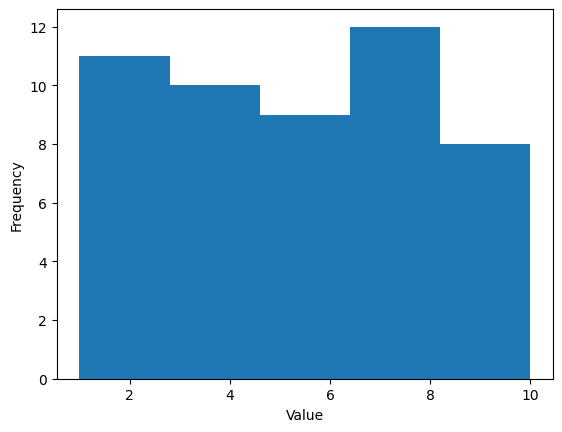

In [145]:
# 28.
# 1. given an array, bin number, plot the histogram
# 2. how to simulate or generate random sample from this histogram?
# 3. how to update the histogram if we add a new number into the array?

# 1.
import matplotlib.pyplot as plt
import numpy as np
import random

data = np.random.randint(0, 11, size=50)
num_bins = 5
plt.hist(data, bins=num_bins)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [108]:
# 2.
freq, bins = np.histogram(data, bins=num_bins)
prob = freq/freq.sum()
sample_size = 10
random_sample = np.random.choice(bins[:-1], size=sample_size, p=prob)
print('random sample: ', random_sample)

random sample:  [8. 8. 0. 0. 4. 2. 0. 0. 8. 6.]


<BarContainer object of 6 artists>

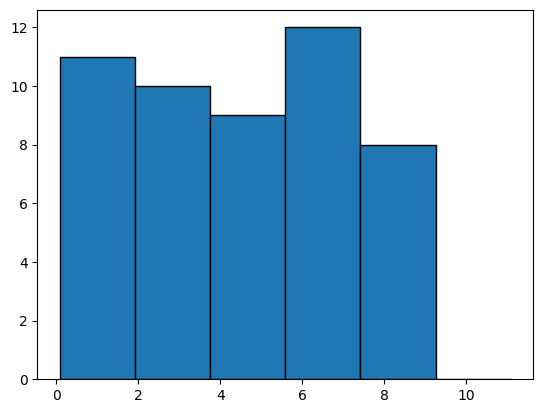

In [146]:
# 3.
# by default, the left edge is included, the right edge is excluded
# num_bins = 5
# data = np.random.randint(0, 11, size=50)
hist, bins = np.histogram(data, bins=num_bins)

new_number = 12

if new_number >= bins[-1]:
    new_bins = np.linspace(bins[0], new_number, num=num_bins + 2)
    hist, bins = np.histogram(data, bins=new_bins)

bin_index = np.digitize([new_number], bins) - 1
if 0 <= bin_index < len(hist):
    hist[bin_index] += 1

plt.bar(bins[:-1], hist, width=np.diff(bins), edgecolor='k')

In [ ]:
# given a target and wordlist, found the top five words with the shortest edit distance
# for example, target = hold, wordlist = [happy, help, hash, coding, want, offer]
# the word in the list with shortest edit distance is help
# the word in the list with second shortest edit distance is hash


# 第二题：给一个 matrix不能用loop，算一个row wise 和column wise 类似 entropy的值 (numpy piesewise operation + sum 应用)
# asked a lot of numpy
# 给定一些string表示的是tweet的post, 有一些tag以#开始, 让返回最经常同时出现的tag pairs.

In [ ]:
# 29
# Given an income list with length of three (income = [i1, i2, i3]) and a mandatory expense list with length of three (mandatory = [m1, m2, m3])
# find a discretionary expense list: discretionary = [d1, d2, d3]
# Need to satisfy the following conditions:
# 1. for the income, need to satisfy the mandatory expense first
# 2. spend all of the money by the end of time
# 3. mazimize the happiness, where happiness = H(d1) + H(d2) + H(d3), and H(x) is a function satisfies first order derivative H'(x)>0 and second order derivative H''(x)<0.
# 4. elements in discretionary cannot be negative
# example: when income = [100, 150, 200] and mandatory = [50, 160, 0], the answer should be discretionary = [20, 20, 200]
# income = [i0, i1, i2], mandatory = [m0, m1, m2], find discretionary = [d0, d1, d2] such that d0*d1*d2 is maximized. 
# The following conditions need to be satisfied: d0>=0, d0<=i0-m0, d1>=0, d1<=i0+i1-m0-m1-d0, d2=i0+i1+i2-m0-m1-m2-d0-d1.

In [1]:
i = [100, 150, 200]
m = [50, 20, 100]

In [3]:
from scipy.optimize import minimize

def objective(x):
    return -(x[0] * x[1] * (sum(i)-sum(m) - x[0] - x[1]))

bounds = [(0, i[0]-m[0]), (0, (i[0]+i[1])-(m[0]+m[1]))]  # Bounds for d1 and d2

constraints = [{'type': 'ineq', 'fun': lambda x: (i[0]+i[1])-(m[0]+m[1]) - x[0] - x[1]}]  # Constraint for d2

initial_guess = [10, 10]  # Starting point for the optimization

result = minimize(objective, initial_guess, bounds=bounds, constraints=constraints)

d1, d2 = result.x
d3 = sum(i)-sum(m) - d1 - d2

# Rounding the results to get a cleaner output
output = [round(d1), round(d2), round(d3)]
output

[50, 115, 115]

In [ ]:
# 30
# Given a m by n matrix with all zero elements and a list of tuples. 
# Each tuple contains three elements (a, b, add), a represents the upper left index, b represents lower right index, add is the number to be added.
# For example, given 5 by 4 matrix, a = 0, b = 5, add = 3, it means we need to add 3 to the 2 by 2 upper left triangle elements, since the indices for the matrix is like:
# [[0, 1, 2, 3], [4, 5, 6, 7], [8, 9, 10, 11], [12, 13, 14, 15], [16, 17, 18, 19]]
# return the maximum value in this matrix.

In [1]:
def max_value_in_matrix(m, n, operations): # m is number of rows, n is number of columns
    matrix = [[0 for _ in range(n)] for _ in range(m)]
    # cannot use matrix = [[0]*n]*m, because:
    # This method creates a single row [0]*n and then replicates the reference to this list m times. 
    # All rows are references to the same list object in memory. 
    # Therefore, when you modify one element in any row, it changes that element in all rows because they are all pointing to the same list.

    for op in operations:
        # Unpack the tuple
        a, b, add = op
        # Calculate the 2D indices from the linear indices
        row1, col1 = divmod(a, n)
        row2, col2 = divmod(b, n)
        
        # Add 'add' to the specified sub-matrix
        for row in range(row1, row2 + 1):
            for col in range(col1, col2 + 1):
                matrix[row][col] += add
                
    # Find the maximum value in the matrix
    max_value = max(max(row) for row in matrix)
    return max_value

In [2]:
operations = [(1, 5, 3), (1, 9, 3)]
max_value_in_matrix(5, 4, operations)

6

In [95]:
def max_value_in_matrix_optimized(m, n, operations):
    # Initialize an auxiliary matrix for marking changes with zeros
    change_matrix = [[0 for _ in range(n)] for _ in range(m)]
    
    # Mark changes in the auxiliary matrix
    for op in operations:
        a, b, add = op
        # Calculate the 2D indices
        row1, col1 = divmod(a, n)
        row2, col2 = divmod(b, n)
        
        change_matrix[row1][col1] += add
        change_matrix[row1][col2 + 1] -= add
        change_matrix[row2 + 1][col1] -= add
        change_matrix[row2 + 1][col2 + 1] += add # This line compensates for the "double" subtraction in the last two steps
    
    # Apply changes and find max value
    max_value = 0

    # Horizontal Sum: As it moves along a row, it updates each cell's value with the sum of itself and all previous cells in the row (horizontal cumulative sum). 
    # This is done using row_sum += change_matrix[row][col]. Vertical Sum: It then adds the value from the cell directly above to account for the vertical cumulative sum. 
    # This is where change_matrix[row][col] = row_sum + (change_matrix[row - 1][col] if row > 0 else 0) comes into play. 
    # If it's the first row, it simply uses the row_sum as there is no cell above.

    for row in range(m):
        row_sum = 0
        for col in range(n):
            row_sum += change_matrix[row][col]
            change_matrix[row][col] = row_sum + (change_matrix[row - 1][col] if row > 0 else 0)
            max_value = max(max_value, change_matrix[row][col])
    
    return max_value

In [96]:
operations = [(1, 5, 3), (1, 9, 3)]
max_value_in_matrix_optimized(5, 4, operations)

6

In [79]:
# 31 O(nk)

def max_number_in_list(n, operations):
    l = [0]*n

    for a, b, add in operations:
        for i in range(a, b+1):
            l[i] += add

    max_num = -float('inf')

    for num in l:
        if num > max_num:
            max_num = num
    
    return max_num


# Example operations
operations = [(0, 2, 100), (1, 4, 100), (0, 0, 100)]
n = 6  # Length of the list

# Find the maximum number in the list after all operations
max_number_in_list(n, operations)

200

In [77]:
# time complexity if O(n+k)

def max_number_in_list(n, operations):
    # Initialize a list with zeros and an extra space for simplifying the end mark handling
    l = [0]*(n+1)
    
    # Marking changes
    for a, b, add in operations:
        l[a] += add
        l[b + 1] -= add  # Mark the end of the addition range
    
    # Applying changes and finding the max value
    max_value = 0
    running_total = 0
    for i in range(n):
        running_total += l[i]
        max_value = max(max_value, running_total)
    
    return max_value


# Example operations
operations = [(0, 2, 100), (1, 4, 100), (0, 0, 100)]
n = 6  # Length of the list

# Find the maximum number in the list after all operations
max_number_in_list(n, operations)

200

In [60]:
# 32. Given a random generator that generates 0 and 1, write a python function to generate any integer between a and b (both inclusive)
# Left Shift Operator (<<): this operation makes room for a new bit on the right side of the number
# Bitwise OR Operator (|): set the least significant bit (the right-most bit) of the current number
# random_bit() generates a 0 or 1 with equal probability, and this value is OR'd with the current (shifted) value of result.
# if random_bit() returns 1, the least significant bit of result is set to 1. If it returns 0, the least significant bit remains 0 (since x | 0 = x).


import math
import random
from collections import Counter

def random_bit():
    return random.randint(0,1)

def generate_random_integer(a, b):
    range_size = b - a + 1
    bits_needed = math.ceil(math.log2(range_size))
    
    while True:
        result = 0
        for _ in range(bits_needed):
            result = (result << 1) | random_bit()
            
        if result < range_size:
            return result + a

In [61]:
result = []

for _ in range(100000):
    result.append(generate_random_integer(1, 10))

Counter(result)

Counter({2: 10140,
         4: 10104,
         9: 10088,
         1: 10043,
         7: 10019,
         8: 10008,
         5: 9999,
         6: 9939,
         10: 9866,
         3: 9794})

In [1]:
# 33. 假如本金10000，每月interest 1%，每个月还500，每个月还的钱先还利息再还本金
# 每个月新的利息如果没还清不产生新的利息（就是没有利滚利），问经过m个月后，还要多少钱没还
# Given principal, monthly interest rate, monthly payment, calculate the unpaid balance after n month
# For the monthly payment, it will be used to pay the interest first
# If interest is not paid off, it won't be added to principal and generate new interest

def unpaid_balance(principal, monthly_interest_rate, monthly_payment, num_month):
    accumulated_interest = 0
    for _ in range(num_month):
        interest = principal*monthly_interest_rate
        accumulated_interest += interest

        if monthly_payment >= accumulated_interest:
            monthly_payment -= accumulated_interest
            principal -= monthly_payment
            accumulated_interest = 0
        else:
            accumulated_interest -= monthly_payment
    return principal

In [ ]:
# practical ML

In [2]:
import pandas as pd
import numpy as np
import random
import math
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_72259/2701914260.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
############################################################################################################################

In [5]:
# regression problem

df = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/insurance.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [9]:
# there is no missing value in the target
# if there is missing value, drop the rows withe missing target

target = 'charges'
df = df.dropna(subset=[target])

In [10]:
# Preparing features and target variable

X = df.drop(target, axis=1)
y = df[target]

In [11]:
# categorical feature
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [12]:
categorical_features

['sex', 'smoker', 'region']

In [13]:
# numerical feature
numerical_features = list(set(X.columns) - set(categorical_features))

In [14]:
numerical_features

['age', 'bmi', 'children']

In [15]:
# Check for missing values in the feature dataframe

missing_values = X.isnull().sum()

In [113]:
# there is no missing value in this specific dataset
# if there is, check the percentage
# if percentage is large, say greater than 30%, drop the column
# if percentage is small, use mean to impute numerical, use mode to input categorical

# example:
# the reason for mode()[0] here is because there might have multiple modes
# inplace means modify the existing dataframe instead of create a new dataframe
X['age'].fillna(X['age'].mean(), inplace=True)
X['sex'].fillna(X['sex'].mode()[0], inplace=True)

/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_56869/1131100710.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].mean(), inplace=True)
/var/folders/vt/p3vf9d352l7fsw1fclffgfsh0000gn/T/ipykernel_56869/1131100710.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [114]:
# Check for outliers in numerical columns
# For simplicity, we'll use the Interquartile Range (IQR) method to flag any values that fall outside of 1.5 * IQR
# This is a common method but keep in mind it's not the only one and not always the best depending on the data distribution

'''
numerical_columns = ['age', 'bmi', 'children', 'charges']
outliers = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    outliers[col] = df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col]

# Initial assessment of missing values and outliers
missing_values, {key: len(value) for key, value in outliers.items()}
'''

"\nnumerical_columns = ['age', 'bmi', 'children', 'charges']\noutliers = {}\n\nfor col in numerical_columns:\n    Q1 = df[col].quantile(0.25)\n    Q3 = df[col].quantile(0.75)\n    IQR = Q3 - Q1\n    lower_bound = Q1 - 1.5*IQR\n    upper_bound = Q3 + 1.5*IQR\n    \n    outliers[col] = df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col]\n\n# Initial assessment of missing values and outliers\nmissing_values, {key: len(value) for key, value in outliers.items()}\n"

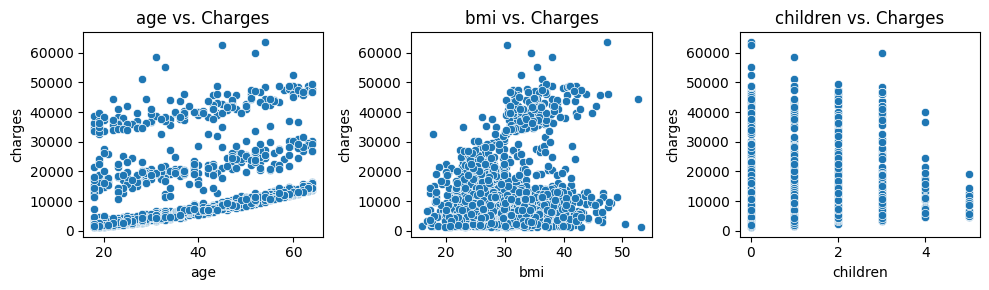

In [20]:
# Creating scatter plots for numerical predictors vs. charges
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, predictor in zip(axes, numerical_features):
    sns.scatterplot(data=df, x=predictor, y='charges', ax=ax)
    ax.set_title(f'{predictor} vs. Charges')

plt.tight_layout()
plt.show()

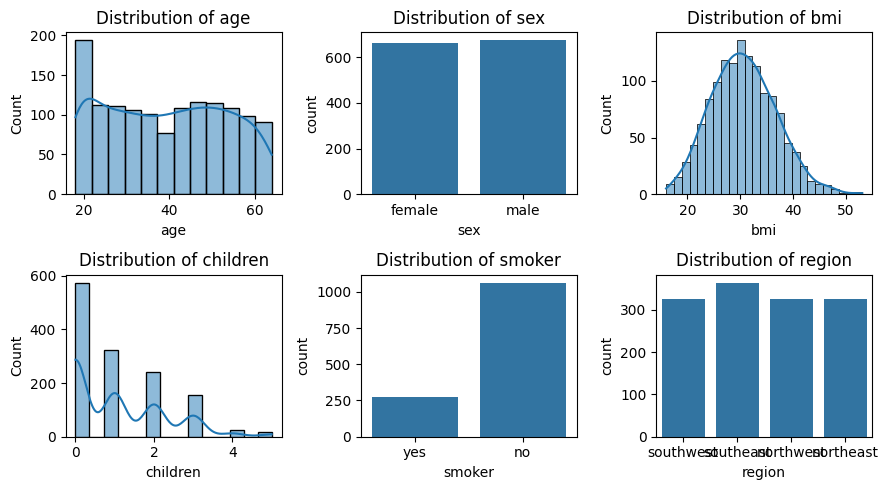

In [21]:
# Creating histograms for all predictors including the categorical ones to understand their distributions
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
predictors = list(X.columns)

for ax, predictor in zip(axes.flatten(), predictors):
    if predictor in categorical_features:
        sns.countplot(data=df, x=predictor, ax=ax)
    else:
        sns.histplot(data=df, x=predictor, kde=True, ax=ax)
    ax.set_title(f'Distribution of {predictor}')

plt.tight_layout()
plt.show()

In [22]:
############################################################################################################################

In [23]:
# linear regression model
# drop_first is to reduce multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler() # (x-mu)/std
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

mse

33596915.85136149

In [24]:
############################################################################################################################

In [25]:
# random forest model
# for random forest in sklearn, need to conduct one-hot encoding

rf_model = RandomForestRegressor(n_estimators=200, max_depth=2, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

mse_rf

24571879.805021804

In [26]:
# Get feature importances from the model
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_arr = []

for i in range(len(feature_importances)):
    importance_arr.append((feature_names[i], feature_importances[i]))

sorted(importance_arr, key=lambda x: x[1], reverse=True)

[('smoker_yes', 0.7366048171831255),
 ('bmi', 0.18359920160971635),
 ('age', 0.07979598120715803),
 ('children', 0.0),
 ('sex_male', 0.0),
 ('region_northwest', 0.0),
 ('region_southeast', 0.0),
 ('region_southwest', 0.0)]

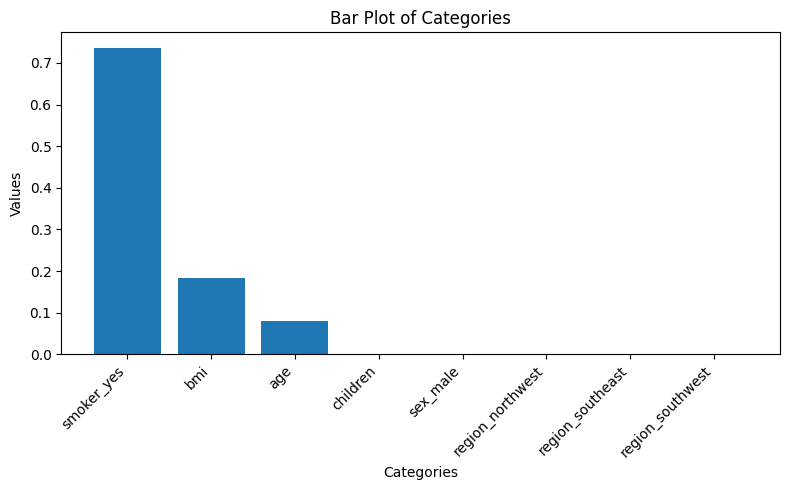

In [32]:
# plot the feature importance
sorted_feature_importance = sorted(importance_arr, key=lambda x: x[1], reverse=True)

# Unpacking the tuples into two lists
features, values = zip(*sorted_feature_importance)

# Creating the bar plot
plt.figure(figsize=(8, 5))
plt.bar(features, values)
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Plot of Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

In [122]:
# grid search cross validation
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200, 500],'max_depth': [2, 5, 10]}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'max_depth': 5, 'n_estimators': 500}, -21945320.096634295)

In [123]:
############################################################################################################################

In [33]:
# classification problem
df = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/loan.csv')
df = df.drop('Loan_ID', axis=1)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             376 non-null    object 
 1   Married            381 non-null    object 
 2   Dependents         373 non-null    object 
 3   Education          381 non-null    object 
 4   Self_Employed      360 non-null    object 
 5   ApplicantIncome    381 non-null    int64  
 6   CoapplicantIncome  381 non-null    float64
 7   LoanAmount         381 non-null    float64
 8   Loan_Amount_Term   370 non-null    float64
 9   Credit_History     351 non-null    float64
 10  Property_Area      381 non-null    object 
 11  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 35.8+ KB


In [35]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [39]:
df_null_cnt = pd.DataFrame(df.isnull().sum())
df_null_cnt = df_null_cnt.reset_index()
df_null_cnt.columns = ['feature', 'null_count']
drop_list = list(df_null_cnt[df_null_cnt['null_count']>0]['feature'])

In [128]:
drop_list

['Gender', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']

In [129]:
df = df.dropna(subset=drop_list)

In [130]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
376,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [131]:
target = 'Loan_Status'
X = df.drop(target, axis=1)
y = df[target]

In [132]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [133]:
############################################################################################################################

In [134]:
# logistic regression

scaler = StandardScaler()
X_encoded_scaled = scaler.fit_transform(X_encoded)
X_train, X_test, y_train, y_test = train_test_split(X_encoded_scaled, y, test_size=0.2, random_state=42)

In [135]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [136]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred_proba)

0.7988095238095237

In [137]:
############################################################################################################################

In [138]:
# Random forest classification
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

rf_auc_score = roc_auc_score(y_test, rf_y_pred_proba)
rf_auc_score

0.8220238095238095

In [139]:
############################################################################################################################

In [ ]:
# load files in different formats in Python
# read csv
df_insurance = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/insurance.csv')
df_loan = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/loan.csv')

# read txt
df = pd.read_csv("txt_file.txt", sep=" ", header=None, names=["Team1", "Team2"])

# read json object
df = pd.read_json('data.json')

# read json string
# Example JSON string
json_string = '{"name": ["John", "Doe"], "age": [28, 34], "city": ["New York", "Chicago"]}'
# Load the JSON string into a pandas DataFrame
df_from_string = pd.read_json(json_string)
# Display the DataFrame
print(df_from_string)

# read json string as dictionary
# Example JSON string
json_string = '{"name": "John", "age": 30, "city": "New York"}'
# Parse the JSON string into a Python dictionary
data = json.loads(json_string)
# Display the dictionary
print(data)
# Accessing an element in the dictionary
print(data['name'])  # Output: John

In [3]:
# pandas operations
df = pd.read_csv('/Users/ganfeng/Documents/Job Application 2023/interview/Block/insurance.csv')

In [4]:
# get the name of the columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
# select column
df_1 = df[['age', 'sex', 'bmi']]

In [6]:
# first 100 rows of select columns

df_2 = df.loc[0:100, ['age', 'sex', 'bmi']]

In [9]:
# sort values by one variable
df_sorted_1 = df.sort_values(by='age', ascending = True)

In [10]:
df_sorted_1

,age,sex,bmi,children,smoker,region,charges
1248,18,female,39.820,0,no,southeast,1633.96180
482,18,female,31.350,0,no,southeast,1622.18850
492,18,female,25.080,0,no,northeast,2196.47320
525,18,female,33.880,0,no,southeast,11482.63485
529,18,male,25.460,0,no,northeast,1708.00140
...,...,...,...,...,...,...,...
398,64,male,25.600,2,no,southwest,14988.43200
335,64,male,34.500,0,no,southwest,13822.80300
378,64,female,30.115,3,no,northwest,16455.70785
1265,64,male,23.760,0,yes,southeast,26926.51440


In [11]:
# sort values by two variables
df_sorted_2 = df.sort_values(by=['age', 'bmi'], ascending=[True, False])

In [12]:
df_sorted_2

,age,sex,bmi,children,smoker,region,charges
1317,18,male,53.13,0,no,southeast,1163.46270
442,18,male,43.01,0,no,southeast,1149.39590
803,18,female,42.24,0,yes,southeast,38792.68560
781,18,male,41.14,0,no,southeast,1146.79660
728,18,female,40.28,0,no,northeast,2217.60120
...,...,...,...,...,...,...,...
1051,64,male,26.41,0,no,northeast,14394.55790
398,64,male,25.60,2,no,southwest,14988.43200
62,64,male,24.70,1,no,northwest,30166.61817
1265,64,male,23.76,0,yes,southeast,26926.51440


In [13]:
# select first five rows

In [14]:
df_sorted_2.iloc[:5]

,age,sex,bmi,children,smoker,region,charges
1317,18,male,53.13,0,no,southeast,1163.4627
442,18,male,43.01,0,no,southeast,1149.3959
803,18,female,42.24,0,yes,southeast,38792.6856
781,18,male,41.14,0,no,southeast,1146.7966
728,18,female,40.28,0,no,northeast,2217.6012


In [15]:
# query

df_q = df.query('10 <= age <= 20')

In [16]:
df_q

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
15,19,male,24.600,1,no,southwest,1837.23700
22,18,male,34.100,0,no,southeast,1137.01100
31,18,female,26.315,0,no,northeast,2198.18985
...,...,...,...,...,...,...,...
1315,18,male,28.310,1,no,northeast,11272.33139
1316,19,female,20.600,0,no,southwest,1731.67700
1317,18,male,53.130,0,no,southeast,1163.46270
1334,18,female,31.920,0,no,northeast,2205.98080


In [17]:
# check missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df.isnull().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

In [20]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
df.isna().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

In [22]:
# check unique values of variable

df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [24]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [25]:
df.nunique()['region']

4

In [26]:
# count values by group - there are two approaches 

In [27]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [28]:
df.groupby('region')['age'].count()

region
northeast    324
northwest    325
southeast    364
southwest    325
Name: age, dtype: int64

In [29]:
# aggreation by group
df.groupby('region')['age'].mean()

region
northeast    39.268519
northwest    39.196923
southeast    38.939560
southwest    39.455385
Name: age, dtype: float64

In [30]:
df.groupby('region')['age'].max()

region
northeast    64
northwest    64
southeast    64
southwest    64
Name: age, dtype: int64

In [31]:
df.groupby('region')['age'].min()

region
northeast    18
northwest    19
southeast    18
southwest    19
Name: age, dtype: int64

In [32]:
# columns with highest n values of selected variable

df.nlargest(5, 'charges')

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209


In [33]:
df.nsmallest(5, 'charges')

,age,sex,bmi,children,smoker,region,charges
940,18,male,23.21,0,no,southeast,1121.8739
808,18,male,30.14,0,no,southeast,1131.5066
1244,18,male,33.33,0,no,southeast,1135.9407
663,18,male,33.66,0,no,southeast,1136.3994
22,18,male,34.10,0,no,southeast,1137.0110


In [38]:
# window function: row number, rank, dense rank
df_3 = df.copy()
df_3 = df_3.sort_values(by='charges', ascending=False)
df_3['row_number'] = df_3.reset_index().index
df_3['rank'] = df_3['charges'].rank(method='min', ascending=False)
df_3['dense_rank'] = df_3['charges'].rank(method='dense', ascending=False)

In [39]:
df_3

,age,sex,bmi,children,smoker,region,charges,row_number,rank,dense_rank
543,54,female,47.410,0,yes,southeast,63770.42801,0,1.0,1.0
1300,45,male,30.360,0,yes,southeast,62592.87309,1,2.0,2.0
1230,52,male,34.485,3,yes,northwest,60021.39897,2,3.0,3.0
577,31,female,38.095,1,yes,northeast,58571.07448,3,4.0,4.0
819,33,female,35.530,0,yes,northwest,55135.40209,4,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...
22,18,male,34.100,0,no,southeast,1137.01100,1333,1334.0,1333.0
663,18,male,33.660,0,no,southeast,1136.39940,1334,1335.0,1334.0
1244,18,male,33.330,0,no,southeast,1135.94070,1335,1336.0,1335.0
808,18,male,30.140,0,no,southeast,1131.50660,1336,1337.0,1336.0


In [42]:
# window function with groupby

df_3 = df.copy()
df_3 = df_3.sort_values(by=['smoker', 'charges'], ascending=[True, False])
df_3['row_number'] = df_3.groupby('smoker').cumcount()
df_3['rank'] = df_3.groupby('smoker')['charges'].rank(method='min')
df_3['dense_rank'] = df_3.groupby('smoker')['charges'].rank(method='dense')

In [43]:
df_3

,age,sex,bmi,children,smoker,region,charges,row_number,rank,dense_rank
1206,59,female,34.800,2,no,southwest,36910.60803,0,1064.0,1063.0
1012,61,female,33.330,4,no,southeast,36580.28216,1,1063.0,1062.0
242,55,female,26.800,1,no,southwest,35160.13457,2,1062.0,1061.0
599,52,female,37.525,2,no,northwest,33471.97189,3,1061.0,1060.0
936,44,male,29.735,2,no,northeast,32108.66282,4,1060.0,1059.0
...,...,...,...,...,...,...,...,...,...,...
412,26,female,17.195,2,yes,northeast,14455.64405,269,5.0,5.0
1282,18,female,21.660,0,yes,northeast,14283.45940,270,4.0,4.0
362,19,female,21.700,0,yes,southwest,13844.50600,271,3.0,3.0
1033,18,male,21.565,0,yes,northeast,13747.87235,272,2.0,2.0


In [44]:
df_3['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [ ]:
# qcut

In [48]:
df_3['charges_cuts'] = pd.qcut(df_3['charges'], q=5, labels=[1, 2, 3, 4, 5])

In [49]:
df_3

,age,sex,bmi,children,smoker,region,charges,row_number,rank,dense_rank,charges_cuts
1206,59,female,34.800,2,no,southwest,36910.60803,0,1064.0,1063.0,5
1012,61,female,33.330,4,no,southeast,36580.28216,1,1063.0,1062.0,5
242,55,female,26.800,1,no,southwest,35160.13457,2,1062.0,1061.0,5
599,52,female,37.525,2,no,northwest,33471.97189,3,1061.0,1060.0,5
936,44,male,29.735,2,no,northeast,32108.66282,4,1060.0,1059.0,5
...,...,...,...,...,...,...,...,...,...,...,...
412,26,female,17.195,2,yes,northeast,14455.64405,269,5.0,5.0,4
1282,18,female,21.660,0,yes,northeast,14283.45940,270,4.0,4.0,4
362,19,female,21.700,0,yes,southwest,13844.50600,271,3.0,3.0,4
1033,18,male,21.565,0,yes,northeast,13747.87235,272,2.0,2.0,4
